In [16]:
import tensorflow as tf 
import csv 
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import os 
RANDOM_SEED = 42

In [29]:
dataset = "Dataset/new_dataset.csv"
model_save_path = '../Saved Models/model.hdf5'

In [3]:
X_dataset = np.loadtxt(dataset,delimiter=',',dtype='float32',usecols=list(range(1,(21*2)+1)))
y_dataset = np.loadtxt(dataset,delimiter=',',dtype='int32',usecols=(0))

In [4]:
NUM_CLASSES = 10

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset,y_dataset,test_size=0.2,random_state=RANDOM_SEED)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([444, 775, 727, 372, 797, 853, 783, 702, 777, 952]))


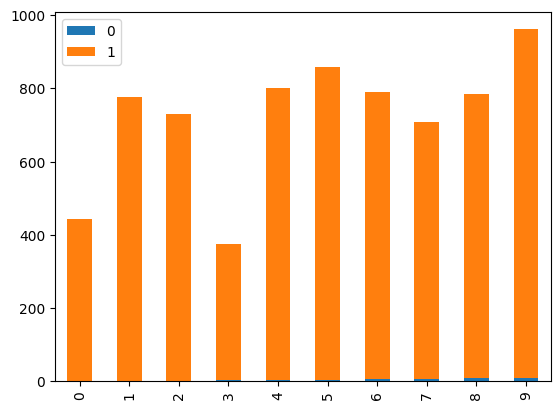

In [6]:
counts = np.unique(y_dataset,return_counts=True)
df = pd.DataFrame(counts)
df.T.plot(kind='bar',stacked =True)
print(counts)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((21 * 2, )),
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.0),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dropout (Dropout)           (None, 42)                0         
                                                                 
 dense (Dense)               (None, 32)                1376      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dense_3 (Dense)             (None, 10)                1

In [31]:
cp_callback = tf.keras.callbacks.ModelCheckpoint(model_save_path,verbose=1,save_weights_only=False,save_best_only=True)
es_callback = tf.keras.callbacks.EarlyStopping(patience=50,verbose=1)

In [32]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
model.fit(
    X_train,
    y_train,
    epochs=1000,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/1000
46/90 [==============>...............] - ETA: 0s - loss: 0.0063 - accuracy: 0.9986     
Epoch 1: val_loss improved from inf to 0.00901, saving model to ../Saved Models/model.hdf5
90/90 [==============================] - 1s 3ms/step - loss: 0.0072 - accuracy: 0.9988 - val_loss: 0.0090 - val_accuracy: 0.9986
Epoch 2/1000
80/90 [=========================>....] - ETA: 0s - loss: 0.0064 - accuracy: 0.9988  
Epoch 2: val_loss improved from 0.00901 to 0.00755, saving model to ../Saved Models/model.hdf5
90/90 [==============================] - 0s 4ms/step - loss: 0.0061 - accuracy: 0.9988 - val_loss: 0.0076 - val_accuracy: 0.9986
Epoch 3/1000
89/90 [============================>.] - ETA: 0s - loss: 0.0044 - accuracy: 0.9988
Epoch 3: val_loss did not improve from 0.00755
90/90 [==============================] - 0s 2ms/step - loss: 0.0043 - accuracy: 0.9988 - val_loss: 0.0103 - val_accuracy: 0.9972
Epoch 4/1000
69/90 [======================>.......] - ETA: 0s - loss: 0.0068 - accura

In [34]:
model = tf.keras.models.load_model(model_save_path)


In [35]:
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=64)

23/23 [==============================] - 0s 1ms/step - loss: 0.0059 - accuracy: 0.9979
